# Do Today’s Strongest Currencies Stay Strong Tomorrow?

## TL;DR

Across **1,298 trading days**, the four strongest currencies on day 0 averaged **-0.0084%** on day 1. The 95% bootstrap confidence interval was **[-0.0177%, +0.0009%]**, which includes zero.

A linear model found a small negative relationship, but day‑0 strength explained only **1.4%** of day‑1 variation.

**Conclusion:** the ranking did not produce a useful continuation signal. At most, the sample suggests weak one-day mean reversion.

## Context & Methods

### Purpose

Test whether the four strongest currencies today tend to remain strong tomorrow.

### Problem

FX prices are quoted as pairs. To compare currencies individually, each pair return is converted into a contribution for its base currency and the opposite contribution for its quote currency.

### Hypothesis

- **Null:** the period average of `top4_next_day_avg` is zero and day‑0 strength does not explain day‑1 strength.
- **Momentum:** the next-day average is positive.
- **Mean reversion:** the next-day average is negative.

### Method

1. Calculate daily percentage changes for 28 pairs built from eight major currencies.
2. Average each currency’s signed contribution across its seven pairs.
3. Select the four strongest currencies each day.
4. Measure those same four currencies on the next trading day.
5. Study the period distribution, mean confidence interval, and day‑0/day‑1 regression.

Because the eight strength scores sum to zero, the bottom-four average is the mirror of the top-four average. Only the top-four result is needed.

In [1]:
# Setup and load the frozen dataset
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

CURRENCIES = ["EUR", "USD", "JPY", "GBP", "CHF", "AUD", "CAD", "NZD"]
DATA_PATH = Path("data/fx_prices_2021-08-01_2026-08-01.csv")
ASSET_DIR = Path("assets")
RANDOM_SEED = 42

BLUE = "#315F8C"
LIGHT_BLUE = "#BDD0E2"
GOLD = "#C58A1B"
INK = "#263442"
GREY = "#788794"
GRID = "#DCE3E8"

ASSET_DIR.mkdir(exist_ok=True)
prices = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)
print(f"{prices.shape[0]:,} dates × {prices.shape[1]} currency pairs")
prices.head(3)

1,300 dates × 28 currency pairs


,EURUSD,EURJPY,EURGBP,EURCHF,EURAUD,EURCAD,EURNZD,USDJPY,USDGBP,USDCHF,...,GBPCHF,GBPAUD,GBPCAD,GBPNZD,CHFAUD,CHFCAD,CHFNZD,AUDCAD,AUDNZD,CADNZD
Date,,,,,,,,,,,,,,,,,,,,,
2021-08-02,1.186704,130.181000,0.85387,1.07492,1.61607,1.47890,1.70120,109.706001,0.71962,0.90591,...,1.25875,1.89250,1.73224,1.99213,1.50326,1.37600,1.58245,0.915220,1.052602,1.14984
2021-08-03,1.187465,129.744003,0.85470,1.07460,1.61319,1.48426,1.69934,109.268997,0.71980,0.90527,...,1.25745,1.88706,1.73636,1.98796,1.50054,1.38071,1.58078,0.920050,1.053520,1.14475
2021-08-04,1.186944,129.360992,0.85279,1.07279,1.60458,1.48753,1.68475,108.990997,0.71850,0.90382,...,1.25779,1.88140,1.74411,1.97513,1.49561,1.38651,1.57016,0.926984,1.049806,1.13230


In [2]:
# Build daily currency-strength scores
pair_returns = prices.pct_change(fill_method=None).mul(100).dropna(how="any")
currency_strength = pd.DataFrame(
    0.0, index=pair_returns.index, columns=CURRENCIES
)

for pair in pair_returns.columns:
    base, quote = pair[:3], pair[3:]
    currency_strength[base] = currency_strength[base] + pair_returns[pair] / 7
    currency_strength[quote] = currency_strength[quote] - pair_returns[pair] / 7

assert pair_returns.shape[1] == 28
assert np.allclose(currency_strength.sum(axis=1), 0, atol=1e-10)

currency_strength.head(3)

,EUR,USD,JPY,GBP,CHF,AUD,CAD,NZD
Date,,,,,,,,
2021-08-03,-0.018463,-0.093800,0.360476,-0.132551,-0.011369,0.198439,-0.410800,0.108069
2021-08-04,-0.271857,-0.230657,0.068322,-0.018395,-0.053613,0.320875,-0.527522,0.712846
2021-08-05,-0.088726,0.221549,-0.337662,-0.000754,-0.127142,0.010487,0.122854,0.199395


In [3]:
# Select each day’s top four and measure the same currencies one day later
top4_by_day = currency_strength.apply(
    lambda row: list(row.nlargest(4).index), axis=1
)

records = []
for position in range(len(top4_by_day) - 1):
    selected = top4_by_day.iloc[position]
    records.append({
        "date": currency_strength.index[position],
        "next_date": currency_strength.index[position + 1],
        "top_4": ", ".join(selected),
        "p0_top4_avg": currency_strength.iloc[position][selected].mean(),
        "top4_next_day_avg": currency_strength.iloc[position + 1][selected].mean(),
    })

next_day_results = pd.DataFrame(records).set_index("date")
next_day_results.head()

,next_date,top_4,p0_top4_avg,top4_next_day_avg
date,,,,
2021-08-03,2021-08-04,"JPY, AUD, NZD, CHF",0.163904,0.262108
2021-08-04,2021-08-05,"NZD, AUD, JPY, GBP",0.270912,-0.032134
2021-08-05,2021-08-06,"USD, NZD, CAD, AUD",0.138571,0.096347
2021-08-06,2021-08-09,"CAD, AUD, GBP, NZD",0.174159,-0.075755
2021-08-09,2021-08-10,"USD, GBP, JPY, CAD",0.279363,0.077396


## Results

In [4]:
# Period-level summary of the daily top-four next-day group averages
outcome = next_day_results["top4_next_day_avg"]
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_means = np.array([
    rng.choice(outcome.to_numpy(), size=len(outcome), replace=True).mean()
    for _ in range(10_000)
])
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])

regression = stats.linregress(
    next_day_results["p0_top4_avg"], outcome
)

summary = pd.Series({
    "observations": len(outcome),
    "period_mean_pct": outcome.mean(),
    "period_median_pct": outcome.median(),
    "ci_95_low_pct": ci_low,
    "ci_95_high_pct": ci_high,
    "regression_slope": regression.slope,
    "regression_r_squared": regression.rvalue ** 2,
    "regression_p_value": regression.pvalue,
})
summary.to_frame("value")

,value
observations,1298.000000
period_mean_pct,-0.008432
period_median_pct,-0.010142
ci_95_low_pct,-0.017726
ci_95_high_pct,0.000925
regression_slope,-0.138959
regression_r_squared,0.013733
regression_p_value,0.000023


C:\Users\Julio\AppData\Local\Temp\ipykernel_5156\1151443297.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


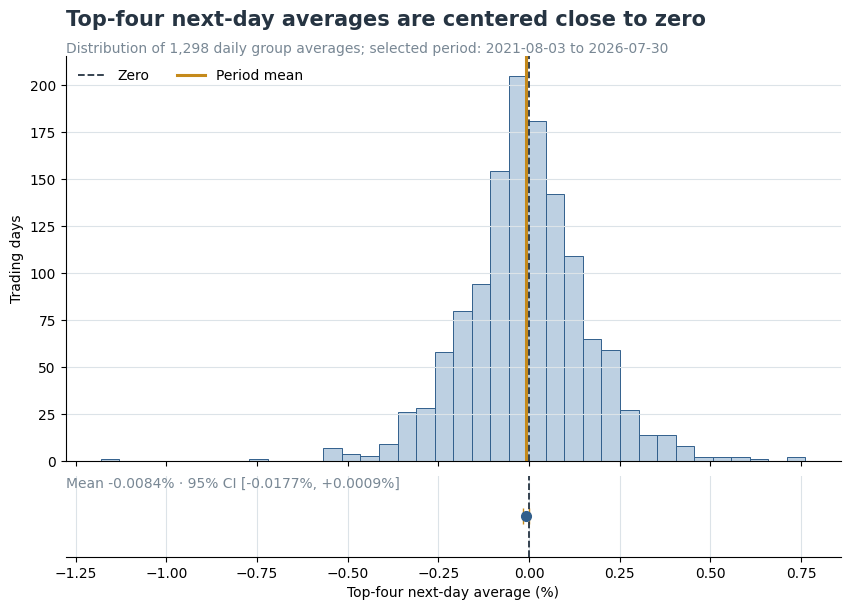

In [5]:
# Visual 1: distribution and uncertainty around the period mean
fig = plt.figure(figsize=(10, 6.5), facecolor="white")
grid = fig.add_gridspec(2, 1, height_ratios=[5, 1], hspace=0.06)
ax = fig.add_subplot(grid[0])
interval_ax = fig.add_subplot(grid[1], sharex=ax)

ax.hist(outcome, bins=38, color=LIGHT_BLUE, edgecolor=BLUE, linewidth=0.7)
ax.axvline(0, color=INK, linestyle="--", linewidth=1.3, label="Zero")
ax.axvline(outcome.mean(), color=GOLD, linewidth=2.2, label="Period mean")
ax.set_ylabel("Trading days")
ax.set_title(
    "Top-four next-day averages are centered close to zero",
    loc="left", fontsize=15, fontweight="bold", color=INK, pad=22
)
ax.text(
    0, 1.01,
    f"Distribution of {len(outcome):,} daily group averages; selected period: "
    f"{outcome.index.min().date()} to {outcome.index.max().date()}",
    transform=ax.transAxes, color=GREY, fontsize=10
)
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelbottom=False)

interval_ax.errorbar(
    outcome.mean(), 0,
    xerr=[[outcome.mean() - ci_low], [ci_high - outcome.mean()]],
    fmt="o", color=BLUE, ecolor=GOLD, elinewidth=3, capsize=6, markersize=7
)
interval_ax.axvline(0, color=INK, linestyle="--", linewidth=1.3)
interval_ax.set_ylim(-0.9, 0.9)
interval_ax.set_yticks([])
interval_ax.set_xlabel("Top-four next-day average (%)")
interval_ax.text(
    0.0, 0.86,
    f"Mean {outcome.mean():+.4f}% · 95% CI [{ci_low:+.4f}%, {ci_high:+.4f}%]",
    transform=interval_ax.transAxes, color=GREY, fontsize=10
)
interval_ax.spines[["top", "right", "left"]].set_visible(False)
interval_ax.grid(axis="x", color=GRID, linewidth=0.8)

plt.tight_layout()
plt.savefig(ASSET_DIR / "top4_next_day_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

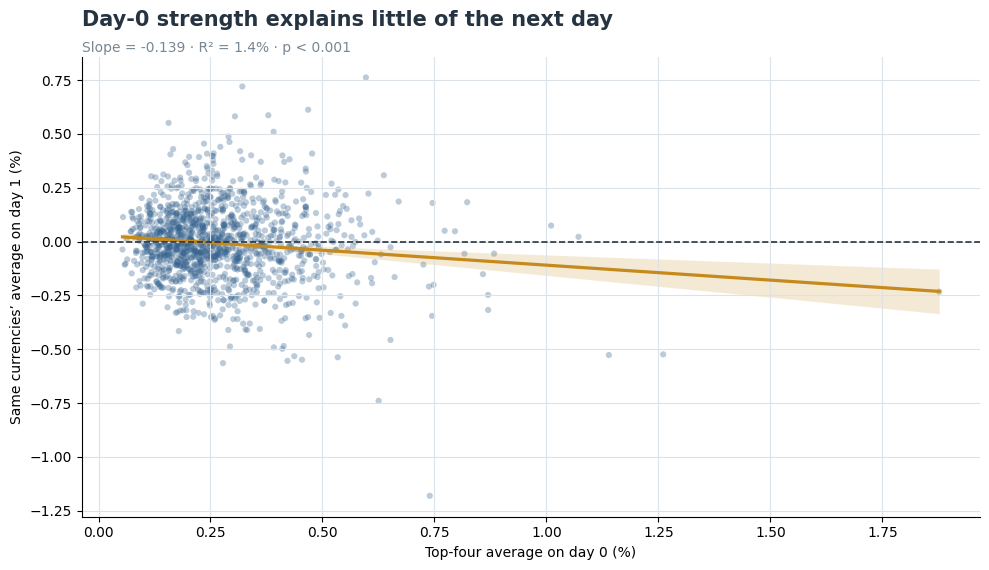

In [6]:
# Visual 2: linear relationship between day 0 and day 1
x = next_day_results["p0_top4_avg"].to_numpy()
y = next_day_results["top4_next_day_avg"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 250)
y_line = regression.intercept + regression.slope * x_line

residuals = y - (regression.intercept + regression.slope * x)
residual_std = np.sqrt(np.sum(residuals ** 2) / (len(x) - 2))
x_centered_sum = np.sum((x - x.mean()) ** 2)
mean_se = residual_std * np.sqrt(
    1 / len(x) + (x_line - x.mean()) ** 2 / x_centered_sum
)
critical_t = stats.t.ppf(0.975, df=len(x) - 2)

fig, ax = plt.subplots(figsize=(10, 5.8), facecolor="white")
ax.scatter(x, y, s=20, alpha=0.32, color=BLUE, edgecolor="none")
ax.plot(x_line, y_line, color=GOLD, linewidth=2.3)
ax.fill_between(
    x_line,
    y_line - critical_t * mean_se,
    y_line + critical_t * mean_se,
    color=GOLD, alpha=0.18, linewidth=0
)
ax.axhline(0, color=INK, linestyle="--", linewidth=1.2)
ax.set_xlabel("Top-four average on day 0 (%)")
ax.set_ylabel("Same currencies’ average on day 1 (%)")
ax.set_title(
    "Day-0 strength explains little of the next day",
    loc="left", fontsize=15, fontweight="bold", color=INK, pad=22
)
p_text = "< 0.001" if regression.pvalue < 0.001 else f"= {regression.pvalue:.3f}"
ax.text(
    0, 1.01,
    f"Slope = {regression.slope:+.3f} · R² = {regression.rvalue ** 2:.1%} · p {p_text}",
    transform=ax.transAxes, color=GREY, fontsize=10
)
ax.grid(color=GRID, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ASSET_DIR / "p0_p1_regression.png", dpi=180, bbox_inches="tight")
plt.show()

## Takeaways

- The period mean was **-0.0084%** and its 95% confidence interval included zero.
- The regression slope was **-0.139**, but $R^2$ was only **1.4%**.
- The data do not support a useful continuation signal.
- The small negative slope suggests weak mean reversion, but its explanatory power is too low to treat as a standalone forecast.

### Limitation

This is an exploratory strength index, not a backtested trading strategy. It does not include spreads, slippage, financing, or out-of-sample testing.